# Compressing Data via Dimensionality Reduction

In this chapter, you will learn about two fundamental techniques that will help you to summarize the information content of a dataset by transforming it onto a new feature subspace of lower dimensionality than the original one.

## Unsupervised dimensionality reduction via principal component analysis

Principal Component Analysis (PCA) is an unsupervised linear transformation technique primarily used for feature extraction and dimensionality reduction. It aims to find the directions of maximum variance in high-dimensional data and project that data onto a new subspace with fewer (or equal) dimensions.

*   **Orthogonality:** The new axes (principal components) are constrained to be orthogonal (uncorrelated) to each other. The first principal component will always capture the largest possible variance.
*   **Sensitivity to Scale:** PCA is highly sensitive to data scaling. It is crucial to standardize your features before applying PCA if they were measured on different scales to assign equal importance to all features.

The 7 Steps of the PCA Algorithm
1.  Standardize the $d$-dimensional dataset.
2.  Construct the covariance matrix.
3.  Decompose the covariance matrix into its eigenvectors and eigenvalues.
4.  Sort the eigenvalues by decreasing order to rank the corresponding eigenvectors.
5.  Select $k$ eigenvectors, which correspond to the $k$ largest eigenvalues, where $k \le d$.
6.  Construct a projection matrix, $W$, from the "top" $k$ eigenvectors.
7.  Transform the $d$-dimensional input dataset, $X$, using the projection matrix, $W$, to obtain the new $k$-dimensional feature subspace.

In [26]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

data, target = load_wine(return_X_y=True, as_frame=True)
X, y = data.values, target.values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=0
)

# Standarize the features
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

# Get eigenvectors and eigenvalues from covarianze matrix
cov_mat = np.cov(X_train_std.T)
eigen_vals, eigen_vecs = np.linalg.eig(cov_mat)
eigen_vecs

array([[-1.3724e-01,  5.0303e-01, -1.3775e-01, -3.2961e-03, -2.9063e-01,
         2.9910e-01,  7.9053e-02, -3.6818e-01, -3.9838e-01, -9.4487e-02,
         3.7464e-01, -1.2783e-01,  2.6283e-01],
       [ 2.4724e-01,  1.6487e-01,  9.6150e-02,  5.6265e-01,  8.9538e-02,
         6.2704e-01, -2.7400e-01, -1.2578e-02,  1.1046e-01,  2.6365e-02,
        -1.3741e-01,  8.0640e-02, -2.6677e-01],
       [-2.5452e-02,  2.4456e-01,  6.7778e-01, -1.0898e-01, -1.6083e-01,
         3.8913e-04,  1.3233e-01,  1.7758e-01,  3.8250e-01,  1.4275e-01,
         4.6158e-01,  1.6792e-02, -1.1554e-01],
       [ 2.0695e-01, -1.1353e-01,  6.2504e-01,  3.3819e-02,  5.1587e-02,
        -4.0584e-02,  2.2400e-01, -4.4059e-01, -2.4337e-01, -1.3049e-01,
        -4.1895e-01, -1.1085e-01,  1.9948e-01],
       [-1.5437e-01,  2.8975e-01,  1.9614e-01, -3.6751e-01,  6.7649e-01,
         6.5777e-02, -4.0527e-01,  1.1662e-01, -2.5898e-01, -6.7608e-02,
         1.0047e-02,  7.9388e-02,  2.8902e-02],
       [-3.9377e-01,  5.0801e-

### Total and explained variance

When using Principal Component Analysis (PCA) to reduce dimensionality, the goal is to compress the dataset into a smaller subspace by selecting the eigenvectors (principal components) that contain the most information, which is measured as variance. Because the eigenvalues define the magnitude of these eigenvectors, we sort them in decreasing order to identify the top $k$ most informative components. Before making this final selection, it is highly useful to calculate the variance explained ratios, which tell us exactly what fraction of the total variance is accounted for by each individual component. This ratio is simply calculated by dividing a specific eigenvalue, $\lambda_j$, by the total sum of all eigenvalues: 

$\text{Explained variance ratio} = \frac{\lambda_j}{\sum_{j=1}^{d} \lambda_j}$.

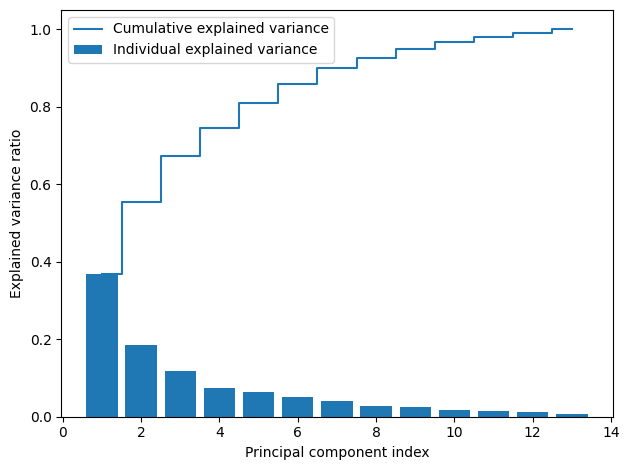

In [27]:
tot = sum(eigen_vals)
var_exp = [(i / tot) for i in
sorted(eigen_vals, reverse=True)]
cum_var_exp = np.cumsum(var_exp)
import matplotlib.pyplot as plt
plt.bar(range(1,14), var_exp, align='center',
label='Individual explained variance')
plt.step(range(1,14), cum_var_exp, where='mid',
label='Cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

### Feature transformation

Now that we have successfully decomposed the covariance matrix into eigenpairs, let’s proceed with
the last three steps to transform the Wine dataset onto the new principal component axes. The remaining steps we are going to tackle in this section are the following:

1. Select k eigenvectors, which correspond to the $k$ largest eigenvalues, where $k$ is the dimensionality of the new feature subspace ($𝑘\le d$).
2. Construct a projection matrix, $W$, from the “top” $k$ eigenvectors.
3. Transform the $d$-dimensional input dataset, $X$, using the projection matrix, $W$, to obtain the
new $k$-dimensional feature subspace.

In [28]:
# Make a list of (eigenvalue, eigenvector) tuples
eigen_pairs = [(np.abs(eigen_vals[i]), eigen_vecs[:, i])
for i in range(len(eigen_vals))]
# Sort the (eigenvalue, eigenvector) tuples from high to low
eigen_pairs.sort(key=lambda k: k[0], reverse=True)

w = np.hstack(
    (
        eigen_pairs[0][1][:, np.newaxis],
        eigen_pairs[1][1][:, np.newaxis]
    )
)
print('Matrix W:\n', w)

Matrix W:
 [[-0.1372  0.503 ]
 [ 0.2472  0.1649]
 [-0.0255  0.2446]
 [ 0.2069 -0.1135]
 [-0.1544  0.2897]
 [-0.3938  0.0508]
 [-0.4174 -0.0229]
 [ 0.3057  0.0905]
 [-0.3067  0.0084]
 [ 0.0755  0.5498]
 [-0.3261 -0.2072]
 [-0.3686 -0.249 ]
 [-0.2967  0.3802]]


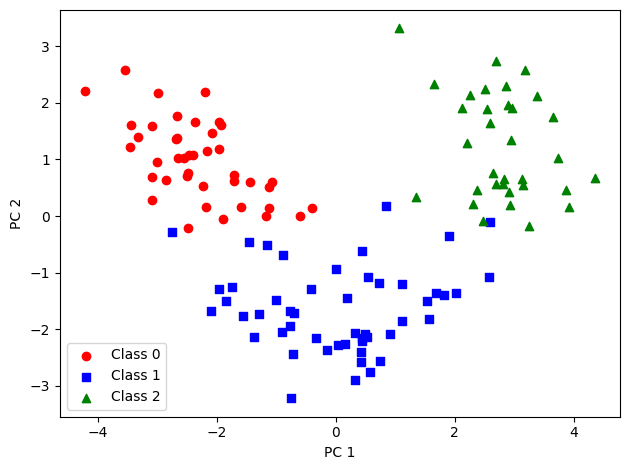

In [29]:
X_train_pca = X_train_std.dot(w)
colors = ['r', 'b', 'g']
markers = ['o', 's', '^']
for l, c, m in zip(np.unique(y_train), colors, markers):
    plt.scatter(X_train_pca[y_train==l, 0],
        X_train_pca[y_train==l, 1],
        c=c, label=f'Class {l}', marker=m)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

### Principal component analysis in scikit-learn

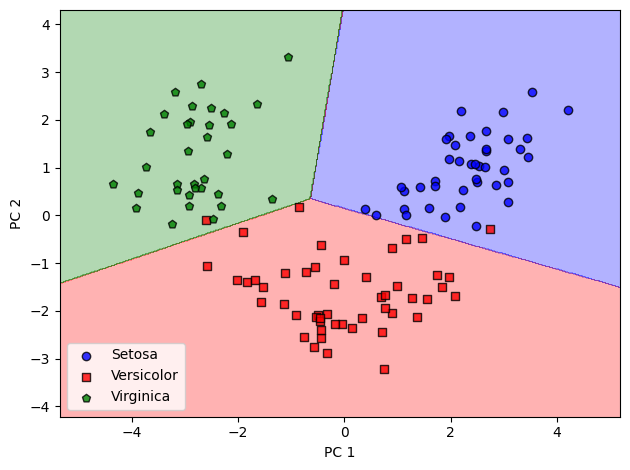

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
import os, sys

# Subimos un nivel en el árbol de directorios ("..") y lo añadimos al path
path_raiz = os.path.abspath("..")
if path_raiz not in sys.path:
    sys.path.append(path_raiz)

from utils.plots import plot_decision_regions

# initializing the PCA transformer and
# logistic regression estimator:
pca = PCA(n_components=2)
lr = LogisticRegression(
    random_state=1,
    solver='lbfgs')
# dimensionality reduction:
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)
# fitting the logistic regression model on the reduced dataset:
lr.fit(X_train_pca, y_train)
plot_decision_regions(X_train_pca, y_train, algorithm=lr)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

If we are interested in the explained variance ratios of the different principal components, we can simply initialize the PCA class with the `n_components` parameter set to None, so all principal components are kept and the explained variance ratio can then be accessed via the `explained_variance_ratio_` attribute:

In [31]:
pca = PCA(n_components=None) # Return all principal components in a sorted order
X_train_pca = pca.fit_transform(X_train_std)
pca.explained_variance_ratio_


array([0.3695, 0.1843, 0.1182, 0.0733, 0.0642, 0.0505, 0.0395, 0.0264,
       0.0239, 0.0163, 0.0138, 0.0117, 0.0082])

## Supervised data compression via linear discriminant analysis

What makes **Linear Discriminant Analysis (LDA)** unique is that it is a **supervised** algorithm. LDA explicitly uses the class labels (categories) attached to the training examples. LDA is a supervised **dimensionality reduction** technique via **feature extration** driven by a main idea: projecting data onto a new feature space where the distance between the centers (means) of different classes is pushed as far apart as possible, while simultaneously compressing the spread (dispersion) of the data points within each individual class so they remain tightly clustered, the fundamental idea behind LDA is the maximization of a specific objective function that represents the ratio of between-class variance to within-class variance.

Mathematically, it seeks a projection matrix $W$ that maximizes the function 

$$J(\mathbf{W}) = \frac{|\mathbf{W}^T \mathbf{S}_B \mathbf{W}|}{|\mathbf{W}^T \mathbf{S}_W \mathbf{W}|}$$

In practical terms, maximizing this function means finding a perspective. By maximizing this exact ratio, the model guarantees minimal overlap between categories, resulting in a highly separable, lower-dimensional dataset.

### The inner workings of linear discriminant analysis

Before we dive into the code implementation, let's briefly summarize the main steps that are required to perform LDA:

1.  Standardize the $d$-dimensional dataset ($d$ is the number of features).

2.  For each class, compute the $d$-dimensional mean vector. Which
we will use to construct the **within-class scatter matrix** $\mathbf{S}_W$ and **between-class scatter matrix** $\mathbf{S}_B$, respectively. Each mean vector, $\mathbf{m}_{i}$, stores the mean feature $\mu_{m}$, with respect to the examples of class $i$:

$$\mathbf{m}_{i}=\dfrac{1}{n_{i}}\sum_{x_{i}\in D_{i}}x_{m}$$

In [32]:
np.set_printoptions(precision=4)
mean_vecs = []
for label in range(3):
    mean_vecs.append(np.mean(
        X_train_std[y_train==label], axis=0))
    print(f'MV {label}: {mean_vecs[label]}\n')

MV 0: [ 0.9066 -0.3497  0.3201 -0.7189  0.5056  0.8807  0.9589 -0.5516  0.5416
  0.2338  0.5897  0.6563  1.2075]

MV 1: [-0.8749 -0.2848 -0.3735  0.3157 -0.3848 -0.0433  0.0635 -0.0946  0.0703
 -0.8286  0.3144  0.3608 -0.7253]

MV 2: [ 0.1992  0.866   0.1682  0.4148 -0.0451 -1.0286 -1.2876  0.8287 -0.7795
  0.9649 -1.209  -1.3622 -0.4013]



3.  Using the mean vectors, construct the within-class scatter matrix, $\boldsymbol{S}_W$.

$$\mathbf{S}_{W}=\sum_{i=0}^{c}\mathbf{S}_{i}$$

This is calculated by summing up the individual scatter matrices, $\mathbf{S}_{i}$, of each individual class i:

$$\mathbf{S}_{i}=\dfrac{1}{n_{i}}\sum_{x_{i}\in D_{i}}(x-\mathbf{m}_{i})(x-\mathbf{m}_{i})^{T}$$

In [33]:
d = 13 # number of features
S_W = np.zeros((d, d))
for label, mv in zip(range(1, 4), mean_vecs):
    class_scatter = np.zeros((d, d))
    n = len(X_train_std[y_train == label])
    for row in X_train_std[y_train == label]:
        row, mv = row.reshape(d, 1), mv.reshape(d, 1)
        class_scatter += (1/n)*(row - mv).dot((row - mv).T)
    S_W += class_scatter
print('Within-class scatter matrix: 'f'{S_W.shape[0]}x{S_W.shape[1]}')

# It is the same than
# d = 13 # number of features
# S_W = np.zeros((d, d))
# for label,mv in zip(range(1, 4), mean_vecs):
#     class_scatter = np.cov(X_train_std[y_train==label].T)
#     S_W += class_scatter
# print('Scaled within-class scatter matrix: 'f'{S_W.shape[0]}x{S_W.shape[1]}')

Within-class scatter matrix: 13x13


4. Using the mean vectors, construct the between-class scatter matrix, $\boldsymbol{S}_B$.

$$\mathbf{S}_{B}=\sum_{i}^{c} n_{i}(\mathbf{m}_{i}-\mathbf{m})(\mathbf{m}_{i}-\mathbf{m})^{T}$$

Here, $\mathbf{m}$ is the overall mean that is computed, including examples from all c classes:

In [34]:
mean_overall = np.mean(X_train_std, axis=0)
mean_overall = mean_overall.reshape(d, 1)
d = 13 # number of features
S_B = np.zeros((d, d))
for i, mean_vec in enumerate(mean_vecs):
    n = X_train_std[y_train == i, :].shape[0]
    mean_vec = mean_vec.reshape(d, 1) # make column vector
    S_B += n * (mean_vec - mean_overall).dot((mean_vec - mean_overall).T)
print('Between-class scatter matrix: ' f'{S_B.shape[0]}x{S_B.shape[1]}')

Between-class scatter matrix: 13x13


5.  The remaining steps of the LDA are similar to the steps of the PCA. However, instead of performing the eigendecomposition on the covariance matrix, we solve the generalized eigenvalue problem of the matrix, $\boldsymbol{S}_W^{-1}\boldsymbol{S}_B$.

In [35]:
eigen_vals, eigen_vecs = np.linalg.eig(np.linalg.inv(S_W).dot(S_B))

6.  Sort the eigenvalues by decreasing order to rank the corresponding eigenvectors.

In [36]:
eigen_pairs = [(np.abs(eigen_vals[i]), eigen_vecs[:,i])
               for i in range(len(eigen_vals))]
eigen_pairs = sorted(eigen_pairs,key=lambda k: k[0], reverse=True)
print('Eigenvalues in descending order:\n')
for eigen_val in eigen_pairs:
    print(eigen_val[0])

Eigenvalues in descending order:

34.875866936141335
14.003980535660666
3.992949780552947e-14
2.964356214747986e-14
2.4132125265805413e-14
1.8441170634682982e-14
1.7553917492010587e-14
1.7553917492010587e-14
1.250351946998927e-14
1.250351946998927e-14
5.822273494257779e-15
3.2995836781039365e-15
3.2995836781039365e-15


In LDA, the number of linear discriminants is at most $c - 1$, where $c$ is the number of class labels, since the in-between scatter matrix, $\boldsymbol{S}_B$, is the sum of $c$ matrices with rank one or less. We can indeed see that we only have two nonzero eigenvalues (the eigenvalues 3-13 are not exactly zero, but this is due to the floating-point arithmetic in NumPy.)

To measure how much of the class-discriminatory information is captured by the linear discriminants (eigenvectors), let's plot the linear discriminants by decreasing eigenvalues, similar to the explained variance plot that we created in the PCA section. For simplicity, we will call the content of class-discriminatory information **discriminability**:

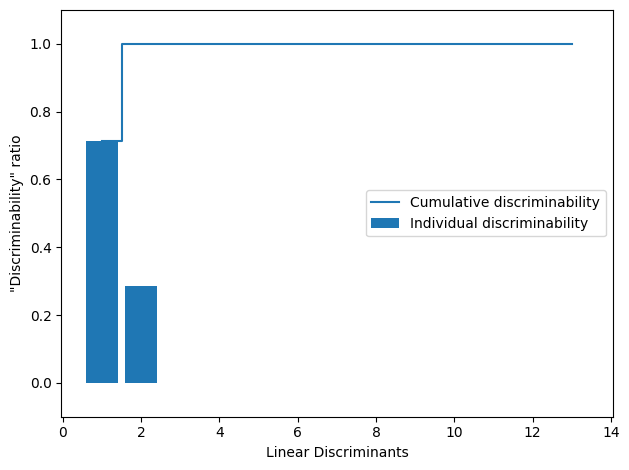

In [37]:
tot = sum(eigen_vals.real)
discr = [(i / tot) for i in sorted(eigen_vals.real, reverse=True)]
cum_discr = np.cumsum(discr)
plt.bar(range(1, 14), discr, align='center', label='Individual discriminability')
plt.step(range(1, 14), cum_discr, where='mid', label='Cumulative discriminability')
plt.ylabel('"Discriminability" ratio')
plt.xlabel('Linear Discriminants')
plt.ylim([-0.1, 1.1])
plt.legend(loc='best')
plt.tight_layout()
plt.show()

7.  Choose the $k$ eigenvectors that correspond to the $k$ largest eigenvalues to construct a $d \times k$-dimensional transformation matrix, $\boldsymbol{W}$; the eigenvectors are the columns of this matrix.

In [38]:
w = np.hstack((
    eigen_pairs[0][1][:, np.newaxis].real,
    eigen_pairs[1][1][:, np.newaxis].real))
print('Matrix W:\n', w)

Matrix W:
 [[-0.1257 -0.2345]
 [ 0.0604 -0.1659]
 [-0.0129 -0.2787]
 [ 0.1847  0.2232]
 [ 0.0837  0.0186]
 [ 0.183  -0.0398]
 [-0.7079  0.3005]
 [-0.0534  0.0363]
 [-0.0071  0.151 ]
 [ 0.2011 -0.275 ]
 [-0.0744  0.1987]
 [-0.238   0.2318]
 [-0.5469 -0.7105]]


8.  Project the examples onto the new feature subspace using the transformation matrix, $\boldsymbol{W}$.

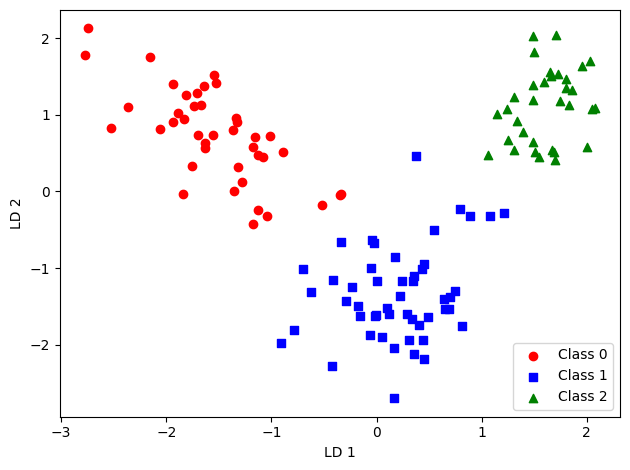

In [39]:
X_train_lda = X_train_std.dot(w)
colors = ['r', 'b', 'g']
markers = ['o', 's', '^']
for l, c, m in zip(np.unique(y_train), colors, markers):
    plt.scatter(X_train_lda[y_train==l, 0],
        X_train_lda[y_train==l, 1] * (-1),
        c=c, label= f'Class {l}', marker=m)
plt.xlabel('LD 1')
plt.ylabel('LD 2')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

As we can see, LDA is quite similar to PCA in the sense that we are decomposing matrices into eigenvalues and eigenvectors, which will form the new lower-dimensional feature space. However, as mentioned before, LDA takes class label information into account, which is represented in the form of the mean vectors computed in *step 2*. In the following sections, we will discuss these seven steps in more detail, accompanied by illustrative code implementations.

### LDA via scikit-learn

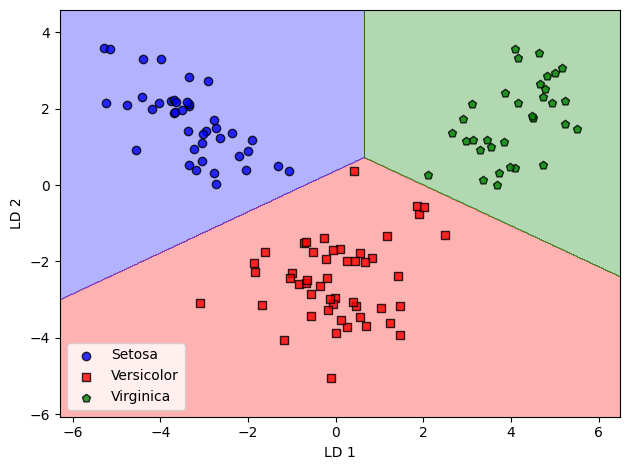

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

# the following import statement is one line
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
lda = LDA(n_components=2)
X_train_lda = lda.fit_transform(X_train_std, y_train)

# lr_multiclass = OneVsRestClassifier(
lr_multiclass = LogisticRegression(
    # penalty='l1',
    l1_ratio=0,
    C=1.0,
    solver='lbfgs'
)
# )
lr_multiclass.fit(X_train_lda, y_train)
plot_decision_regions(X_train_lda, y_train, algorithm=lr_multiclass)
plt.xlabel('LD 1')
plt.ylabel('LD 2')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()